In [1]:
import numpy as np
import pathlib 
import pickle
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

import morph_analyses as m


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [ ]:
cellnums = []
for rf, mouse_dict in zip(('rare', 'freq'), (m.mouse_metadata.rare_sessions, m.mouse_metadata.frequent_sessions)):

    for mouse in mouse_dict.keys():
        cellnum = []
        train, test = mouse_dict[mouse]['training_sessions'], mouse_dict[mouse]['test_sessions']

        for tt, tup in {'training': train, 'testing': test}.items():
            
            for sess_deets in tup:
                
                sess = m.sess.CA1MorphSession.from_nwb(mouse, tt, sess_deets['day'])
                cellnums.append({
                    'rare_freq': rf,
                    'mouse': mouse,
                    'day': sess_deets['day'],
                    'ncells': sess.timeseries['spks'].shape[0]
                })
df = pd.DataFrame(cellnums)
    

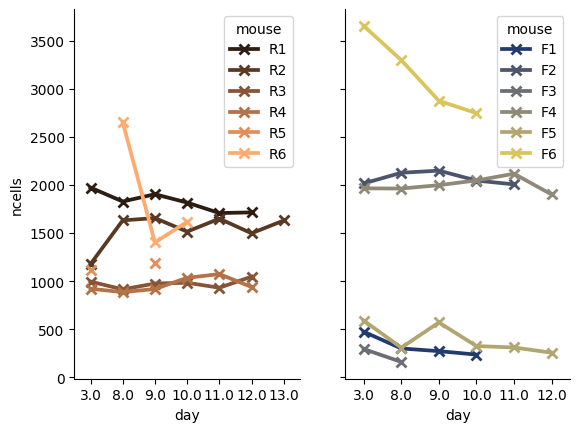

In [5]:
fig, ax = plt.subplots(1,2, sharey=True)
mask = (df['day']==3) + (df['day']>=8)
df = df.loc[mask,:]
sns.pointplot(
    data=df.loc[df['rare_freq']=='rare',:],
    x = 'day',
    y = 'ncells',
    hue='mouse',
    ax = ax[0],
    palette='copper',
    markers='x', 
)
sns.pointplot(
    data=df.loc[df['rare_freq']=='freq',:],
    x = 'day',
    y = 'ncells',
    hue='mouse',
    ax = ax[1],
    palette='cividis',
    markers='x',
)


for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    # a.set_xticks(np.arange(3,14,1))